## Notebook de analise de metricas de saida dos modelos treinados

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn torch -q


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import sys
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt


In [3]:
## Read files 
df1_pred = np.float32(np.load('../output/metricas/train/fold_0/predict_label_train_fold_0.npy', allow_pickle=True))
df1_true = np.float32(np.load('../output/metricas/train/fold_0/true_label_train_fold_0.npy', allow_pickle=True))

In [4]:
(df1_pred)

array([], shape=(50, 0), dtype=float32)

In [5]:
def calc_loss(outputs, labels):
    criterio = nn.CrossEntropyLoss()
    acc = []
    for i in range(len(outputs)):
        #print(f'Size of output {i}: {outputs[i].shape}, Size of label {i}: {labels[i].shape}')
        loss = criterio(outputs[i], labels[i])
        acc.append(loss.item())
        #print(f'Loss for sample {i}: {loss.item()}')
    return sum(acc) / len(acc)


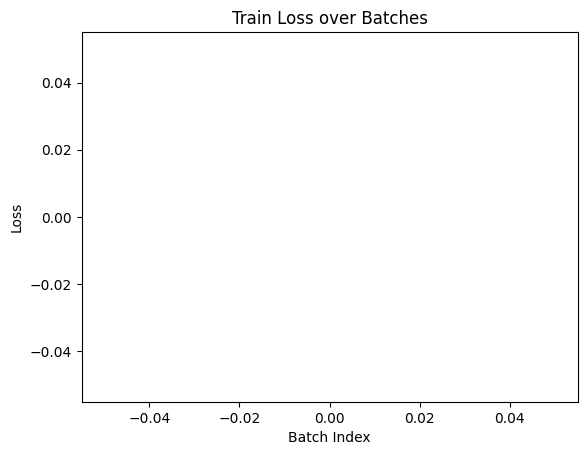

In [6]:
criterio = nn.BCEWithLogitsLoss()
total_loss = []
for i in range(len(df1_pred)):
    outputs_tensor = torch.tensor(df1_pred[i]).to(torch.float)
    labels_tensor = torch.tensor(df1_true[i]).to(torch.float)
    #print(outputs_tensor.shape, labels_tensor.shape)
    loss = criterio(outputs_tensor, labels_tensor)
    #loss = calc_loss(outputs_tensor, labels_tensor)
    total_loss.append(loss)
    #print(f'Loss for batch {i}: {loss}')
plt.plot(total_loss)
plt.title('Train Loss over Batches')
plt.xlabel('Batch Index')
plt.ylabel('Loss')
plt.show()

## Loop to print all train

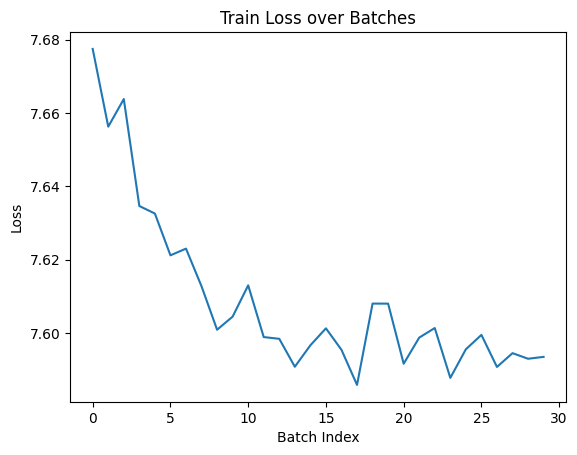

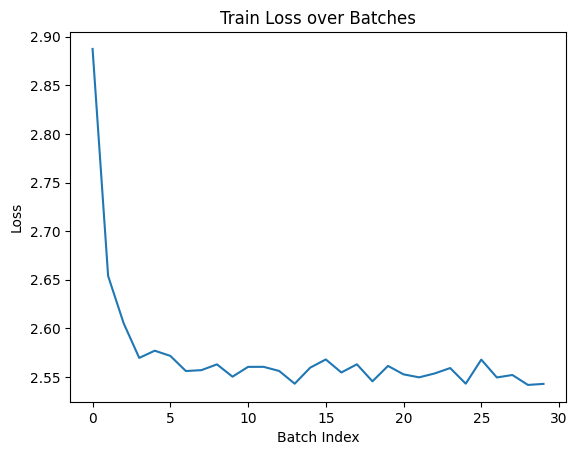

FileNotFoundError: [Errno 2] No such file or directory: '../saida_400/saidas/output/metricas/train/fold_2/predict_label_train_fold_2.npy'

In [8]:
## Read files 
N_fold = 5

for i in range(N_fold):
    df1_pred = np.float32(np.load(f'../saida_400/saidas/output/metricas/train/fold_{i}/predict_label_train_fold_{i}.npy', allow_pickle=True))
    df1_true = np.float32(np.load(f'../saida_400/saidas/output/metricas/train/fold_{i}/true_label_train_fold_{i}.npy', allow_pickle=True))
    criterio = nn.CrossEntropyLoss()
    total_loss = []
    for j in range(len(df1_pred)):
        outputs_tensor = torch.tensor(df1_pred[j]).to(torch.float)
        labels_tensor = torch.tensor(df1_true[j]).to(torch.float)
        #print(outputs_tensor.shape, labels_tensor.shape)
        #loss = criterio(outputs_tensor, labels_tensor)
        loss = calc_loss(outputs_tensor, labels_tensor)/len(df1_pred)
        total_loss.append(loss)
        #print(f'Loss for batch {i}: {loss}')
    plt.plot(total_loss)
    plt.title('Train Loss over Batches')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.show()

In [9]:
## Calculo precisao, recall e f1 score
from sklearn.metrics import precision_score, recall_score, f1_score
for i in range(len(df1_pred)):
    outputs_tensor = torch.tensor(df1_pred[i]).to(torch.float)
    labels_tensor = torch.tensor(df1_true[i]).to(torch.float)
    
    # Convertir las predicciones a etiquetas binarias (0 o 1) usando un umbral de 0.5
    predicted_labels = (outputs_tensor > 0.5).int().numpy()
    true_labels = labels_tensor.int().numpy()
    
    precision = precision_score(true_labels, predicted_labels, average='micro')
    recall = recall_score(true_labels, predicted_labels, average='micro')
    f1 = f1_score(true_labels, predicted_labels, average='micro')
    

In [10]:
m = nn.Sigmoid()
loss = nn.BCELoss()
input = torch.randn(3, 2, requires_grad=True)
target = torch.rand(3, 2, requires_grad=False)
output = loss(m(input), target)
output

tensor(0.7971, grad_fn=<BinaryCrossEntropyBackward0>)

In [ ]:
loss2 = nn.BCEWithLogitsLoss()
output2 = loss2(input, target)
output2

tensor(0.5955, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [ ]:
input

tensor([[-0.7277, -0.0600],
        [ 0.6944, -0.0539],
        [ 1.4066, -1.1549]], requires_grad=True)

In [ ]:
target

tensor([[0.4189, 0.4996],
        [0.7083, 0.1365],
        [0.9922, 0.3420]])

In [ ]:
loss2 = nn.BCEWithLogitsLoss()
output2 = loss2(input, target)
output2

tensor(0.5955, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)